# Data Preprocessing for scDiffusion

This notebook performs preprocessing on the raw h5ad data:
- Filtering cells and genes
- Normalization and log transformation
- Highly Variable Genes (HVG) selection (1024 genes)
- Z-score normalization

HVG 1024 version (20251218)

In [1]:
import scanpy as sc
import os
import argparse

## Configuration

In [2]:
# Input data path
data_dir = "/home/suzuki/Projects/scDiffusion/data_preparation/pbmc68k.h5ad"

# # Output path for preprocessed data
# output_suffix = "_PREPROCESS_20260122.h5ad"
# preprocessed_path = data_dir.replace('.h5ad', output_suffix)

preprocessed_path="/home/suzuki/Projects/scDiffusion/work/20260122_1_ReconstructUMAP/pbmc68k_preprocessed_20260122.h5ad"

## Load Data

In [3]:
print("Loading h5ad file...")
adata = sc.read_h5ad(data_dir)
print(f"Original data shape: {adata.shape}")

Loading h5ad file...


Original data shape: (68579, 32738)


In [ ]:
adata

In [4]:
adata.X.sum(axis=1)

matrix([[1216.],
        [1265.],
        [1322.],
        ...,
        [1230.],
        [ 552.],
        [1761.]], dtype=float32)

## Filtering

In [4]:
# Apply filtering
print("Applying filtering...")
sc.pp.filter_cells(adata, min_genes=10)
sc.pp.filter_genes(adata, min_cells=3)
print(f"Data shape after filtering: {adata.shape}")

Applying filtering...
Data shape after filtering: (68579, 17789)


## Normalization and Log Transformation

In [5]:
# Apply normalization and log transformation
print("Applying normalization and log transformation...")
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
print("Normalization and log transformation completed")

Applying normalization and log transformation...
Normalization and log transformation completed


## Highly Variable Genes (HVG) Selection

In [6]:
# --- HVG selection ---
print("Selecting highly variable genes...")
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=1024,         # HVG 1024 genes (20251218 version)
    # flavor="seurat_v3",     # Optional: specify flavor if needed (e.g., 'seurat_v3')
    subset=True,               # Subset to HVG only
    inplace=True
)
print(f"Number of HVG kept: {adata.n_vars}")

Selecting highly variable genes...


/home/suzuki/.conda/envs/scdiffusion_jupyter/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:216: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersions']


Number of HVG kept: 1024


## Z-score Normalization

In [7]:
# Apply z-score normalization
print("Applying z-score normalization...")
sc.pp.scale(adata, zero_center=True)
print("Z-score normalization completed")

Applying z-score normalization...
Z-score normalization completed


## Save Preprocessed Data

In [14]:
# Save preprocessed data
print(f"Saving preprocessed data to: {preprocessed_path}")
adata.write(preprocessed_path)
print("Preprocessing completed successfully!")

Saving preprocessed data to: /home/suzuki/Projects/scDiffusion/work/20260122_1_ReconstructUMAP/pbmc68k_preprocessed_20260122.h5ad
Preprocessing completed successfully!


## Verification

In [8]:
# Verify the saved data
print("\n=== Verification ===")
print(f"Final data shape: {adata.shape}")
print(f"adata.var columns: {list(adata.var.columns)}")
print(f"'gene_name' column exists in adata.var: {'gene_name' in adata.var.columns}")
print(f"adata.obs columns: {list(adata.obs.columns)}")
print(f"'celltype' column exists in adata.obs: {'celltype' in adata.obs.columns}")
print(f"adata.n_vars (number of genes): {adata.n_vars}")
print(f"adata.n_obs (number of cells): {adata.n_obs}")


=== Verification ===
Final data shape: (68579, 1024)
adata.var columns: ['gene_id', 'gene_name', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std']
'gene_name' column exists in adata.var: True
adata.obs columns: ['TSNE.1', 'TSNE.2', 'celltype', 'n_genes']
'celltype' column exists in adata.obs: True
adata.n_vars (number of genes): 1024
adata.n_obs (number of cells): 68579


# UMAP確認

In [9]:
import matplotlib.pyplot as plt
# ノートブックのパラメータに準拠
sc.tl.pca(adata, svd_solver='arpack', n_comps=50)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=40)
sc.tl.umap(adata)

/home/suzuki/.conda/envs/scdiffusion_jupyter/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/suzuki/.conda/envs/scdiffusion_jupyter/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


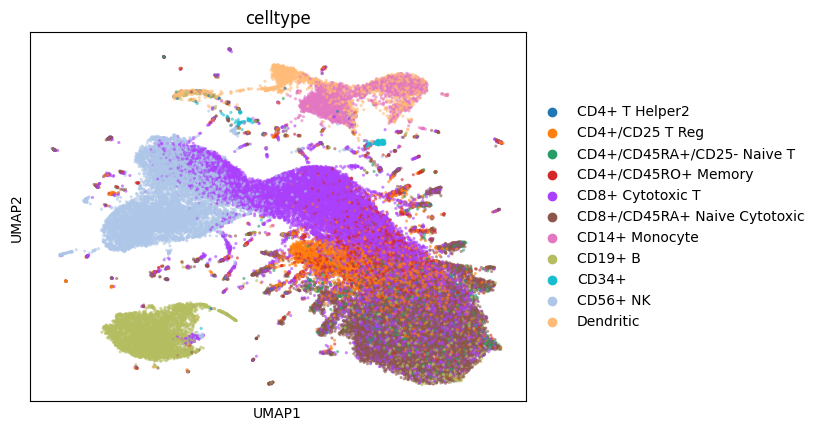

In [12]:
sc.pl.umap(adata, color="celltype", 
            size=20, alpha=0.6)

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def plot_loss_curves(loss_csv_path, output_dir):
    if not os.path.exists(loss_csv_path):
        return None

    try:
        df = pd.read_csv(loss_csv_path)
    except Exception as e:
        print(f"Error reading loss CSV: {e}")
        return None

    fig, ax1 = plt.subplots(figsize=(12, 8))

    # 左軸：メイン損失
    if 'original_loss' in df.columns:
        ax1.plot(
            df['step'], df['original_loss'],
            label='Reconst Error',
            linestyle='-',
            color='blue',
            linewidth=2,
            alpha=0.8,
        )

    if 'total_loss' in df.columns:
        ax1.plot(
            df['step'], df['total_loss'],
            label='Total Loss',
            linestyle='-',
            color='red',
            linewidth=2,
            alpha=0.8,
        )

    ax1.set_xlabel('Training Steps')
    ax1.set_ylabel('Loss Value')
    ax1.set_title('Training Loss Curves')
    ax1.grid(True, alpha=0.3)

    # 右軸：正則化（緑）
    ax2 = None
    if 'reg_weighted' in df.columns:
        ax2 = ax1.twinx()
        ax2.plot(
            df['step'], df['reg_weighted'],
            label='Weighted Reg (λ*Reg)',
            linestyle='-',
            color='green',
            linewidth=1.8,
            alpha=0.8,
        )
        ax2.set_ylabel('Regularization Loss', color='green')
        ax2.tick_params(axis='y', colors='green')
        ax2.spines['right'].set_color('green')

    # legend を “ax1 と ax2” から集めて結合（重複除去つき）
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = (ax2.get_legend_handles_labels() if ax2 is not None else ([], []))

    # 同名ラベルがあったら潰す（後勝ちで1個になる）
    uniq = dict(zip(l1 + l2, h1 + h2))
    ax1.legend(uniq.values(), uniq.keys(), loc='upper right')

    os.makedirs(output_dir, exist_ok=True)
    loss_plot_path = os.path.join(output_dir, "loss_curves_compare.png")
    fig.savefig(loss_plot_path, dpi=300, bbox_inches='tight')
    plt.close(fig)
    return loss_plot_path


In [25]:
plot_loss_curves("/home/suzuki/Projects/scDiffusion/work/20260122_1_ReconstructUMAP/20260122_162354_MINIMUMTEST/20260122_162355_train/checkpoints/pbmc68k_soft_20251127_hvg1024/loss_details.csv",
                 "/home/suzuki/Projects/scDiffusion/work/20260122_1_ReconstructUMAP/20260122_162354_MINIMUMTEST/20260122_162424_viz")

'/home/suzuki/Projects/scDiffusion/work/20260122_1_ReconstructUMAP/20260122_162354_MINIMUMTEST/20260122_162424_viz/loss_curves_simple.png'